In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Import the poisson distribution from scipy.stats
from scipy.stats import poisson, norm

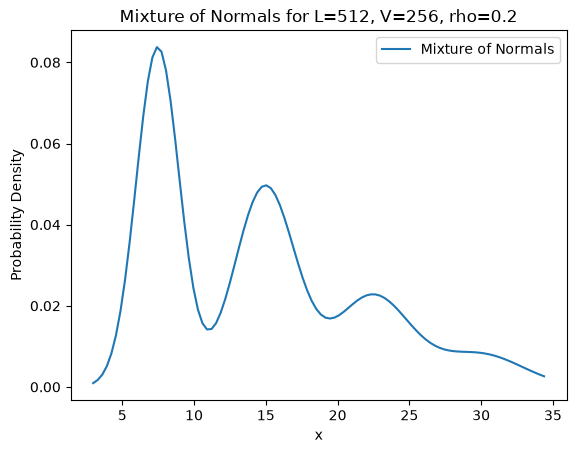

In [13]:
L = 512
V = 256
rho = 0.2 
K = int(rho*V)
beta = 0.25
omega = 300.0

lam = L/((1+rho)*V)


h_on = beta * K * omega / L
std_base = 1.5
ells = np.arange(1,5)
weigths_ells = poisson.pmf(ells, lam)

x_vals = np.linspace(h_on - 3*std_base,h_on*ells[-1]+3*std_base,100)
y_vals = np.zeros_like(x_vals)
for ell, weight in zip(ells, weigths_ells):
    std = std_base * np.sqrt(ell)
    y_vals += weight * norm.pdf(x_vals, loc=h_on*ell, scale=std)


plt.plot(x_vals, y_vals, label='Mixture of Normals')
plt.title('Mixture of Normals for L={}, V={}, rho={}'.format(L, V, rho))
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()